In [1]:
import sys

sys.path.append("..")

In [2]:
import os
import json
import glob
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

from config import config, AppConfig
from data.data_loader import CREMADDataset
from models.model import build_model
from utils.model import (
    build_criterion,
    create_loaders,
    get_device,
    load_checkpoint,
)

/Users/morteza/w/univercity/MLInVision/HW5/homework_code/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
PLOT_DIR = "../../report/images"
os.makedirs(PLOT_DIR, exist_ok=True)
SAVE_DIR = "../models/saved_models"
DEVICE = get_device()
print(f"Device: {DEVICE}")
print(f"Feature: {config.feature.extractor}")

Device: mps
Feature: hubert


In [4]:
models = os.listdir(SAVE_DIR)
best_model_feature = None
best_model_acc = 0.0
for model in models:
    if not model.endswith(".pt"):
        continue
    model = model.replace(".pt", "")
    acc = float(model.split("best_acc=")[-1])
    if acc > best_model_acc:
        best_model_acc = acc
        best_model_feature = model.split("_")[0]
print(
    f"Best model feature: {best_model_feature}, Best model accuracy: {best_model_acc}"
)
best_model_ckpt = os.path.join(
    SAVE_DIR, f"{best_model_feature}_best_acc={best_model_acc:.4f}.pt"
)

model = build_model(config, override_extractor=best_model_feature).to(DEVICE)
ckpt = load_checkpoint(best_model_ckpt, DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()
print(f"Loaded epoch {ckpt['epoch']} with val_acc={ckpt['val_acc']:.4f}")

Best model feature: hubert, Best model accuracy: 0.8611
Loaded epoch 18 with val_acc=0.8611


In [5]:
_, _, test_loader = create_loaders(config)
criterion = build_criterion(config)

Loading weights: 100%|██████████| 211/211 [00:00<00:00, 65207.64it/s]


In [6]:
all_preds = []
all_labels = []
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        features = batch["features"].to(DEVICE)
        labels = batch["label"].to(DEVICE)
        print(features.shape)
        outputs = model(features)
        loss = criterion(outputs, labels)
        test_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        test_correct += (preds == labels).sum().item()
        test_total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_accuracy = test_correct / test_total
test_loss_avg = test_loss / test_total
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print(f"\nTest Accuracy : {test_accuracy:.4f}")
print(f"Test Loss     : {test_loss_avg:.4f}")

Test: 100%|██████████| 1/1 [00:04<00:00,  4.08s/it]

torch.Size([107, 149, 768])

Test Accuracy : 0.7757
Test Loss     : 0.7057


Emotion classes: ['NEU', 'HAP', 'ANG', 'SAD']


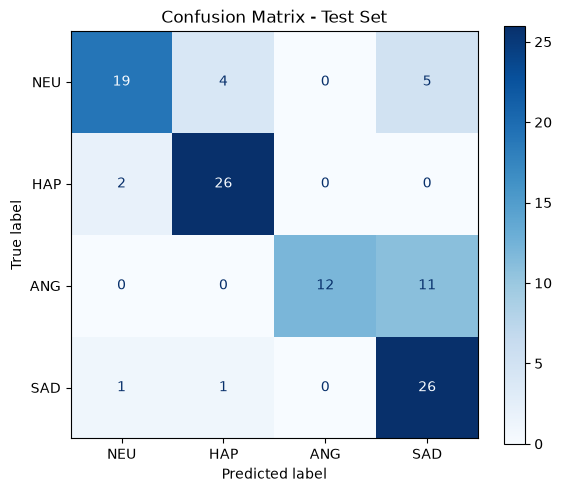

In [7]:
emotions = config.dataset.emotions
print("Emotion classes:", emotions)

cm = confusion_matrix(all_labels, all_preds, labels=range(len(emotions)))
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotions)
disp.plot(cmap=plt.cm.Blues, ax=ax)
ax.set_title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.savefig(
    os.path.join(PLOT_DIR, "confusion_matrix.png"), dpi=150, bbox_inches="tight"
)
plt.show()

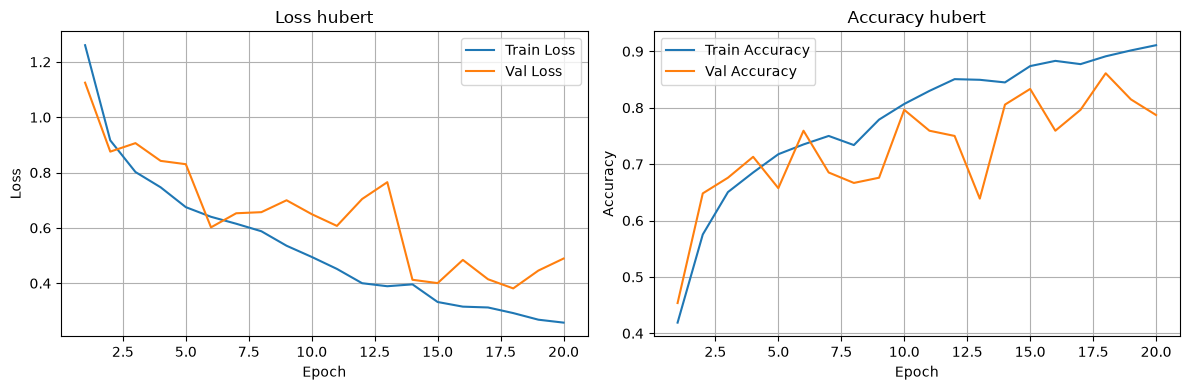

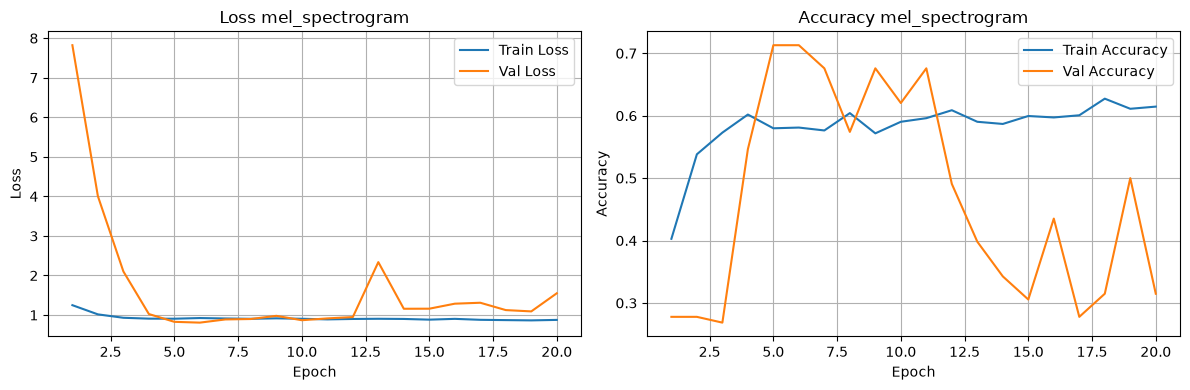

In [11]:
for extractor_name in ("hubert", "mel_spectrogram"):
    history_path = os.path.join(SAVE_DIR, f"history_{extractor_name}.json")
    if not os.path.exists(history_path):
        raise FileNotFoundError(
            f"{history_path} not found. Run `PYTHONPATH=. uv run python scripts/main.py train` first.\n"
        )

    with open(history_path, "r") as f:
        history_data = json.load(f)

    history = history_data["history"]
    epochs = [h["epoch"] for h in history]
    train_losses = [h["train_loss"] for h in history]
    train_accs = [h["train_acc"] for h in history]
    val_losses = [h["val_loss"] for h in history]
    val_accs = [h["val_acc"] for h in history]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, train_losses, label="Train Loss")
    axes[0].plot(epochs, val_losses, label="Val Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title(f"Loss {extractor_name}")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, train_accs, label="Train Accuracy")
    axes[1].plot(epochs, val_accs, label="Val Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title(f"Accuracy {extractor_name}")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f"training_curves_{extractor_name}.png"), dpi=150, bbox_inches="tight")
    plt.show()